In [1]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

# SFTDS funds

In [2]:
# Data prep
query = f"""

SELECT DISTINCT borrower_id AS entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy IN ('EUR', 'USD')

"""

df_sftds_borr = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\2028002566.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sftds_borr = pd.read_sql_query(query, cnxn)


In [3]:
len(df_sftds_borr)

5653

In [4]:
# Data prep
query = f"""

SELECT DISTINCT lender_id AS entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy IN ('EUR', 'USD')

"""

df_sftds_lend = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\1977673262.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sftds_lend = pd.read_sql_query(query, cnxn)


In [5]:
len(df_sftds_lend)

56989

In [6]:
df_sftds = pd.concat([df_sftds_borr, df_sftds_lend]).drop_duplicates().reset_index(drop=True)

In [7]:
len(df_sftds)

59497

# EMIR Funds

In [8]:
# Data prep
query = f"""

SELECT DISTINCT other_cpty_id as entity_id
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR", "USD")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'IF' OR s_entity.sector = 'OFI' OR s_entity.sector = 'OTHR' OR other_cpty_id_esa_sector_riad = 'S124')

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\4075289031.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [9]:
len(df_emir_refit)

7385

In [10]:
# Data prep
query = f"""


SELECT DISTINCT other_cpty_id as entity_id
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR", "USD")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'IF' OR s_entity.sector = 'OFI' OR s_entity.sector = 'OTHR' OR other_cpty_id_esa_sector = 'S124')


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\2521852953.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [11]:
len(df_emir_old)

14358

In [12]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [13]:
len(df_emir)

15814

In [14]:
df_emir.head()

,entity_id
0,549300D8IEUHUNDW1K56
1,95980020140005313255
2,9695006JMSSMC26MV072
3,959800N174RDRQF4RA66
4,5493007BFQ2M6VYB5412


# Overlap analysis

In [15]:
df_overlap = pd.merge(df_sftds, df_emir, on='entity_id', how='inner')

In [16]:
len(df_overlap)

1071

In [17]:
# Data prep
query = f"""

SELECT id as entity_id, subsector, if_strategy
FROM lab_prj_emir_ecb.mbf_sector_enrichment_20250328

"""

df_sectors = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\155897054.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sectors = pd.read_sql_query(query, cnxn)


In [18]:
df_overlap = df_overlap.merge(df_sectors, on = 'entity_id', how = 'left')

## Remove UCITs
- UCITS (Undertakings for Collective Investment in Transferable Securities) are highly regulated investments funds (mutual funds or ETFs) that have to conform to safety standards under EU and UK regulation

In [19]:
df_overlap = df_overlap[((df_overlap['subsector'] != 'UCIT') & (df_overlap['subsector'] != 'AM')) | (df_overlap['if_strategy'] == 'Hedge')]

In [20]:
df_overlap['if_strategy'].value_counts(dropna = False)

if_strategy
None         170
Other        149
NaN           86
Bonds         68
Mixed         41
Hedge         28
Bond           6
nan            4
Equities       4
Bond-govt      1
PE             1
Name: count, dtype: int64

In [21]:
overlap = tuple(df_overlap['entity_id'].unique())

In [22]:
# Data prep
query = f"""

SELECT entity_id, country
FROM (
    SELECT 
        borrower_id AS entity_id,
        borrower_country_residence as country,
        ROW_NUMBER() OVER (
            PARTITION BY borrower_id 
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_id IN {overlap}
    GROUP BY borrower_id, borrower_country_residence
) sub
WHERE rn = 1

"""

df_countries_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\2439288253.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_countries_borrowing = pd.read_sql_query(query, cnxn)


In [23]:
# Data prep
query = f"""

SELECT entity_id, country
FROM (
    SELECT 
        lender_id AS entity_id,
        lender_country_residence as country,
        ROW_NUMBER() OVER (
            PARTITION BY lender_id 
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_id IN {overlap}
    GROUP BY lender_id, lender_country_residence
) sub
WHERE rn = 1

"""

df_countries_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\3033834130.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_countries_lending = pd.read_sql_query(query, cnxn)


In [24]:
df_countries = pd.concat([df_countries_borrowing, df_countries_lending]).drop_duplicates(subset='entity_id').reset_index(drop=True)

In [25]:
len(df_countries)

555

In [26]:
df_overlap = df_overlap.merge(df_countries, on = 'entity_id', how = 'left')

In [27]:
# Data prep
query = f"""

SELECT entity_id, name
FROM (
    SELECT 
        borrower_id AS entity_id,
        borrower_name as name,
        ROW_NUMBER() OVER (
            PARTITION BY borrower_id 
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_id IN {overlap}
    GROUP BY borrower_id, borrower_name
) sub
WHERE rn = 1

"""

df_name_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\115623470.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_name_borrowing = pd.read_sql_query(query, cnxn)


In [28]:
# Data prep
query = f"""

SELECT entity_id, name
FROM (
    SELECT 
        lender_id AS entity_id,
        lender_name as name,
        ROW_NUMBER() OVER (
            PARTITION BY lender_id 
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_id IN {overlap}
    GROUP BY lender_id, lender_name
) sub
WHERE rn = 1

"""

df_name_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_24288\175980377.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_name_lending = pd.read_sql_query(query, cnxn)


In [29]:
df_name = pd.concat([df_name_borrowing, df_name_lending]).drop_duplicates(subset='entity_id').reset_index(drop=True)

In [30]:
df_overlap = df_overlap.merge(df_name, on = 'entity_id', how = 'left')

In [31]:
df_overlap['country'].value_counts(dropna=False)

country
ES    241
FR     61
DE     43
KY     42
GB     30
LU     20
DK     15
IE     14
IT      9
HU      9
PL      7
HR      7
US      6
NL      6
AU      5
MT      5
CH      5
BG      3
SE      3
HK      3
GG      3
NO      2
KR      2
VG      2
AE      2
SG      1
ZA      1
CA      1
GR      1
CZ      1
CY      1
BM      1
MY      1
TW      1
MC      1
AZ      1
JE      1
NZ      1
Name: count, dtype: int64

## Removing SICAVs
-  SICAVs (Sociedades de Inversión de Capital Variable) are open-ended collective investment companies, commonly used by high-net-worth individuals to manage large estates. SICAVs are typically regulated, long-only investment vehicles, more comparable to mutual funds in structure.

In [32]:
df_countries[df_countries['country']=='ES'].to_excel('SICAV.xlsx')

In [33]:
spanish_hedge_funds = ['95980020140005918826',
'213800NC4JZ8W5NOGG65',
'95980020140005080746',
'95980020140005521029',
'959800R15GAP1ZWLAA07',
'95980020140005270963',
'95980020140005324022',
'95980020140005992352'
]

In [34]:
df_overlap = df_overlap[(df_overlap['country'] != 'ES') | (df_overlap['entity_id'].isin(spanish_hedge_funds))]

## Removing french entities
- The majority are associated with LBPAM, CNP, AXA, or MATIGNON which are banks, insurance firms, or pension funds/diversified funds/mutual funds. The others I have googled are also mututal or pension funds

In [35]:
df_overlap = df_overlap[df_overlap['country'] != 'FR']

In [36]:
len(df_overlap)

264

## Removing german funds
- these are almost all associated with Allianz or Suzuka, Merlin, the latter being 'KAGBs' which are vehicles to put your money in in case you are very rich and are worried that your bank goes bust

In [37]:
df_overlap[df_overlap['country'] == 'DE']

,entity_id,subsector,if_strategy,country,name
9,549300MPWOPFLWR5U308,AIFD,Mixed,DE,Allianz PV 1 Fonds
20,L5B73Z7Y846FLWTQMU88,AIFD,Mixed,DE,Suzuka INKA
23,5493003PW2WZIQ32DP83,AIFD,Mixed,DE,MERLIN Master Fonds INKA
24,529900J0YFYQDW75EV18,AIFD,Mixed,DE,None
42,529900H2Y17B1LIB6Z90,AIFD,Mixed,DE,Allianz PV-WS Fonds
50,529900UDHI4DP50JDR68,AIFD,Bonds,DE,MI-FONDS K22
53,549300I5FGD97GY1C248,AIFD,Bonds,DE,Allianz FAD Fonds
90,549300O22WZHXE6EZ231,AIFD,Mixed,DE,DIM
91,549300RXL27MZ9RQEV81,AIFD,Mixed,DE,RZVK - Fonds
98,549300WC9ZLCYTJZX181,AIFD,Bonds,DE,None


In [38]:
df_overlap = df_overlap[df_overlap['country'] != 'DE']

## Removing some UK entities
- Amundi is part of a french asset manager and vantage is a broker dealer. The rest seem to be genuine hedge funds

In [39]:
import pandas as pd

# Update the map with the UK entities
uk_map = {
    # Hedge Funds (and Absolute Return / Macro)
    'Redhedge Synergy Total Return': 'Hedge Fund',
    'REDHEDGE ICAV - RV - CORPORATE BONDS FUND': 'Hedge Fund',
    'H2O ALLEGRO FCP': 'Hedge Fund',
    'H2O MULTIBONDS FCP': 'Hedge Fund',
    'LATIN AMERICA OPPORTUNITIES FUND': 'Hedge Fund',
    'ELAN CAPITAL MANAGEMENT LLP': 'Hedge Fund',
    'CAPULA INVESTMENT MANAGEMENT LLP': 'Hedge Fund',
    'LMR PARTNERS LLP': 'Hedge Fund',
    'BANOR ALTERNATIVE ASSETS - Enhanced Carry Hedged Opportunity': 'Hedge Fund',
    'DRW GLOBAL MARKETS LTD': 'Hedge Fund', # Proprietary trading firm

    # Asset Managers (Traditional/Institutional)
    'INSIGHT INVESTMENT MANAGEMENT (GLOBAL) LIMITED': 'Asset Manager',
    'BLACKROCK INVESTMENT MANAGEMENT (UK) LIMITED': 'Asset Manager',
    'AMUNDI (UK) LIMITED': 'Asset Manager',
    'COLUMBIA THREADNEEDLE MANAGEMENT LIMITED': 'Asset Manager',
    'MI BREWIN DOLPHIN INVESTMENT FUNDS - MI Select Managers Bond Fund': 'Mutual Fund',

    # Brokers, Investment Banks & Market Infrastructure
    'STONEX FINANCIAL LTD': 'Asset Manager/Broker',
    'BGC BROKERS L.P.': 'Asset Manager/Broker',
    'JEFFERIES INTERNATIONAL LIMITED': 'Asset Manager/Broker',
    'BRITANNIA GLOBAL MARKETS LIMITED': 'Asset Manager/Broker',
    'WELLS FARGO SECURITIES INTERNATIONAL LIMITED': 'Asset Manager/Broker',
    'MUFG SECURITIES EMEA PLC': 'Asset Manager/Broker',
    'VANTAGE CAPITAL MARKETS LLP': 'Asset Manager/Broker',
    'TP ICAP MARKETS LIMITED': 'Asset Manager/Broker',
    'TP ICAP BROKING LIMITED': 'Asset Manager/Broker',
    'KYTE BROKING LIMITED': 'Asset Manager/Broker',
    'SUCDEN FINANCIAL LIMITED': 'Asset Manager/Broker',

    # Development Banks
    'EUROPEAN BANK FOR RECONSTRUCTION AND DEVELOPMENT': 'Institutional Strategy'
}

# Apply to dataframe
df_overlap['category'] = df_overlap['name'].map(uk_map).fillna('Other')

In [40]:
df_overlap[df_overlap['country'] == 'GB']

,entity_id,subsector,if_strategy,country,name,category
0,5493007BY9KSQEUZNW97,AIFD,Bond,GB,MI BREWIN DOLPHIN INVESTMENT FUNDS - MI Select...,Mutual Fund
2,213800NR44FZFC9RPO56,None,None,GB,INSIGHT INVESTMENT MANAGEMENT (GLOBAL) LIMITED,Asset Manager
3,63540017ASS7JJLVRO84,AIFD,Bonds,GB,Redhedge Synergy Total Return,Hedge Fund
16,549300AWF3TOHRYL7754,None,None,GB,STONEX FINANCIAL LTD,Asset Manager/Broker
45,9695005Q5S0QJFDR1T70,None,None,GB,H2O ALLEGRO FCP,Hedge Fund
47,ZWNFQ48RUL8VJZ2AIC12,None,None,GB,BGC BROKERS L.P.,Asset Manager/Broker
59,969500D188QI2AULBJ98,None,None,GB,None,Other
65,S5THZMDUJCTQZBTRVI98,None,None,GB,JEFFERIES INTERNATIONAL LIMITED,Asset Manager/Broker
101,GUNTJCA81C7IHNBGI392,None,None,GB,None,Other
112,BWS7DNS2Z4NPKPNYKL75,None,None,GB,WELLS FARGO SECURITIES INTERNATIONAL LIMITED,Asset Manager/Broker


In [41]:
df_overlap = df_overlap[(df_overlap['country'] != 'GB') | (df_overlap['category'] == 'Hedge Fund')]

In [42]:
len(df_overlap)

201

In [43]:
df_overlap['country'].value_counts(dropna=False)

country
KY    42
LU    20
DK    15
IE    14
GB    10
HU     9
IT     9
ES     8
HR     7
PL     7
US     6
NL     6
MT     5
AU     5
CH     5
BG     3
HK     3
GG     3
SE     3
NO     2
AE     2
VG     2
KR     2
SG     1
ZA     1
CA     1
GR     1
CZ     1
CY     1
BM     1
JE     1
MY     1
TW     1
MC     1
AZ     1
NZ     1
Name: count, dtype: int64

## The remainder

In [44]:
df_overlap[(df_overlap['country'].isin(['KY', 'ES', 'GB']) == False) & (df_overlap['if_strategy'] != 'Hedge')]

,entity_id,subsector,if_strategy,country,name,category
1,529900E0IPJD4O9FDS04,AIFD,Bonds,HU,OTP Maxima Kötvény Alap,Other
4,549300KKMY8XC2HPZ142,None,None,CH,IBKR Financial Services AG,Other
5,259400UYS8PY5FNI5F14,None,None,PL,GENERALI ABSOLUTE RETURN DŁUŻNY FUNDUSZ INWEST...,Other
6,549300R8VJDW3X6CD250,None,None,KR,한국투자증권 주식회사,Other
7,25940076ZA2U325EQS45,None,None,PL,SUBFUNDUSZ SGB OBLIGACJI UNIWERSALNY,Other
...,...,...,...,...,...,...
521,6354006O14T3JQZRTP05,None,None,IE,Redhedge Relative Value UCITS Fund,Other
526,549300KDZNTRN3I31G35,None,None,NZ,Mercer Overseas Fixed Interest Trust,Other
528,549300FJ4N473SBSQ656,AIFD,Other,LU,CONVERTIBLE ARBITRAGE,Other
540,HB1B4C2Y54HM6BM6EN48,None,None,NO,SYKEHJELPS- OG PENSJONSORDNING FOR LEGER (SOP),Other


In [45]:
import pandas as pd

# Updated Mapping dictionary for clean classification
clean_map = {
    # --- Hedge Funds (Includes Arbitrage, Absolute Return, and "Lite" strategies) ---
    'OTP Sigma Nyíltvégű Származtatott Alap': 'Hedge Fund',
    'GENERALI ABSOLUTE RETURN DŁUŻNY FUNDUSZ INWESTYCYJNY ZAMKNIĘTY': 'Hedge Fund',
    'Suntheta Fund': 'Hedge Fund',
    'Danske Invest Hedge Fixed Income Opportunities Fund': 'Hedge Fund',
    'ASGARD GLOBAL FIXED INCOME RISK PREMIA': 'Hedge Fund',
    'Stratus Master Limited': 'Hedge Fund',
    'GLOBAL RATES OPPORTUNITY FUND': 'Hedge Fund',
    'Global Rates Fund': 'Hedge Fund',
    'NORDIC RATES OPPORTUNITY FUND II': 'Hedge Fund',
    'OTP Supra Származtatott Befektetési Alap': 'Hedge Fund',
    'EUROPEAN RATES OPPORTUNITY FUND': 'Hedge Fund',
    'Bridgewater Pure Alpha Trading Company, Ltd.': 'Hedge Fund',
    'Asgard Fixed Income Risk Premia': 'Hedge Fund',
    'NEXT VALUE BOND STRATEGIES': 'Hedge Fund',
    'Gardena Alternative ICAV - Gardena Global Multi-Strategy Fund': 'Hedge Fund',
    'NORDIC RATES OPPORTUNITY FUND': 'Hedge Fund',
    'Gardena Bond Absolute Return Fund': 'Hedge Fund',
    'Antiloop Hedge': 'Hedge Fund',
    'RSJ Prop Podfond': 'Hedge Fund',
    'Gardena Alternative ICAV - Gardena Euro Govies Fund': 'Hedge Fund',
    'Credit Alpha': 'Hedge Fund',
    'CONVERTIBLE ARBITRAGE': 'Hedge Fund',
    'Redhedge Relative Value UCITS Fund': 'Hedge Fund',
    'Stichting Juridisch Eigendom Mint Tower Arbitrage Fund': 'Hedge Fund',

    # --- Mutual Funds (Regulated retail/institutional bond & equity funds) ---
    'Pekao Funduszy Globalnych SFIO subfundusz Pekao Spokojna Inwestycja': 'Mutual Fund',
    'OTP Maxima Kötvény Alap': 'Mutual Fund',
    'SUBFUNDUSZ SGB OBLIGACJI UNIWERSALNY': 'Mutual Fund',
    'STANLIB Funds Limited - STANLIB Multi-Manager Global Bond Fund': 'Mutual Fund',
    'OTP Stratégiai Euró Kötvény Alap': 'Mutual Fund',
    'SUBFUNDUSZ GENERALI OBLIGACJI UNIWERSALNY PLUS': 'Mutual Fund',
    'PIMCO INFLATION RESPONSE MULTI-ASSET': 'Mutual Fund',
    'OTP II. Zártkörű Kötvény Alap': 'Mutual Fund',
    'PKO STRATEGII DŁUŻNYCH FUNDUSZ INWESTYCYJNY ZAMKNIĘTY': 'Mutual Fund',
    'OTP Tőkegarantált Rövid Kötvény Alap': 'Mutual Fund',
    'PKO SUBFUNDUSZ OBLIGACJI SKARBOWYCH ŚREDNIOTERMINOWY': 'Mutual Fund',
    'InterCapital Conservative Balanced': 'Mutual Fund',
    'OTP Optima Tőkegarantált Kötvény Alap': 'Mutual Fund',
    'SUBFUNDUSZ GENERALI OBLIGACJE AKTYWNY': 'Mutual Fund',
    'ARCA REDDITO VALORE REALE 2027': 'Mutual Fund',
    'ARCA REDDITO VALORE REALE 2027 II': 'Mutual Fund',
    'ARCA REDDITO VALORE REALE 2027 III': 'Mutual Fund',
    'OTP Meta Globális Kötvény Alap': 'Mutual Fund',
    'Enhanced Ultra Short Term Bond SRI FAM Fund': 'Mutual Fund',
    'ROBECO TRANSITION ASIAN BONDS': 'Mutual Fund',
    'CLIMATE ULTRA SHORT TERM BOND': 'Mutual Fund',
    'ARCA MULTI-STRATEGY PRUDENTE 2026 VI': 'Mutual Fund',
    'ARCA MULTI-STRATEGY PRUDENTE 2026 VII': 'Mutual Fund',
    'ARCA MULTI-STRATEGY PRUDENTE 2026 VIII': 'Mutual Fund',

    # --- Pension & Sovereign Wealth Funds (The Asset Owners) ---
    'CARESUPER': 'Pension/Sovereign Fund',
    'FROST': 'Pension/Sovereign Fund',
    'Abu Dhabi Investment Authority': 'Pension/Sovereign Fund',
    'REALDANIA': 'Pension/Sovereign Fund',
    'HESTA': 'Pension/Sovereign Fund',
    'ARCA PREVIDENZA': 'Pension/Sovereign Fund',
    'SHELL INTERNATIONAL PENSION FUND': 'Pension/Sovereign Fund',
    'EMPLOYEES PROVIDENT FUND BOARD': 'Pension/Sovereign Fund',
    'NATIONAL PENSION INSURANCE FUND': 'Pension/Sovereign Fund',
    'FOLKETRYGDFONDET': 'Pension/Sovereign Fund',
    'Australian Retirement Trust': 'Pension/Sovereign Fund',
    'THE STATE OIL FUND OF THE REPUBLIC OF AZERBAIJAN': 'Pension/Sovereign Fund',
    'SYKEHJELPS- OG PENSJONSORDNING FOR LEGER (SOP)': 'Pension/Sovereign Fund',
    'Zwitserleven Long Duration Fund': 'Pension/Sovereign Fund',
    'EUROPEAN STABILITY MECHANISM': 'Pension/Sovereign Fund',
    'PFA Kapitalforening - Afdeling 5 - PFA Udenlandske Obligationer': 'Pension/Sovereign Fund',
    'PFA Kapitalforening - Afdeling 10 - PFA Danske Realkreditobligationer': 'Pension/Sovereign Fund',
    'Afdeling 7 - PFA Investment Grade Obligationer': 'Pension/Sovereign Fund',

    # --- Asset Managers, Brokers, & Market Infrastructure ---
    'IBKR Financial Services AG': 'Asset Manager/Broker',
    '한국투자증권 주식회사': 'Asset Manager/Broker', # Korea Investment & Securities
    'Kepler Cheuvreux (Suisse) SA': 'Asset Manager/Broker',
    '國泰君安證券投資(香港)有限公司': 'Asset Manager/Broker', # Guotai Junan
    'Leonteq Securities AG': 'Asset Manager/Broker',
    'CITADEL SECURITIES GCS (IRELAND) LIMITED': 'Asset Manager/Broker',
    '華泰資本投資有限公司': 'Asset Manager/Broker', # Huatai Capital
    'TD GLOBAL FINANCE UNLIMITED COMPANY': 'Asset Manager/Broker',
    'ИП ИНТЕРКАПИТΑΛ ΜΑΡΚΕΤS': 'Asset Manager/Broker',
    'INTERKAPITAL vrijednosni papiri d.o.o.': 'Asset Manager/Broker',
    'Absa Bank Limited': 'Asset Manager/Broker',
    'J&E Davy Unlimited Company': 'Asset Manager/Broker',
    'NBC GLOBAL FINANCE LIMITED': 'Asset Manager/Broker',
    "BANOR SOCIETA' DI INTERMEDIAZIONE MOBILIARE S.P.A.": 'Asset Manager/Broker',
    'SUSQUEHANNA INTERNATIONAL GROUP LIMITED': 'Asset Manager/Broker',
    'STONEX FINANCIAL INC.': 'Asset Manager/Broker',
    'Bank Vontobel AG': 'Asset Manager/Broker',
    'RBC DOMINION SECURITIES INC.': 'Asset Manager/Broker',
    'RENAISSANCE SECURITIES (CYPRUS) LIMITED': 'Asset Manager/Broker',
    'SG AMERICAS SECURITIES, LLC': 'Asset Manager/Broker',
    'ДЕЛТАСТОК': 'Asset Manager/Broker', # Deltastock
    'ЕЛАНΑ ΤΡЕЙДИНΓ': 'Asset Manager/Broker', # Elana Trading
    'ABN AMRO CLEARING USA LLC': 'Asset Manager/Broker',
    'GOLDMAN SACHS ASSET MANAGEMENT, L.P.': 'Asset Manager/Broker',
    'ICAM DYNAMIC ALLOCATION': 'Asset Manager/Broker',
    'ICAM CONSERVATIVE PRIVATE': 'Asset Manager/Broker',
    'Stichting Depositary APG Developed Markets Active Credits Pool': 'Asset Manager/Broker',
    'Complus Asset Management Limited': 'Asset Manager/Broker',
    'Würth Finance International B.V.': 'Asset Manager/Broker',

    # --- Institutional Strategies / Dedicated Mandates ---
    'AeAM Strategic Liability Matching Fund': 'Institutional Strategy',
    'PORTFINANCE SICAV P.L.C.': 'Institutional Strategy',
    'KOBRA Master': 'Institutional Strategy',
    'Mira Master': 'Institutional Strategy',
    'PPIM Core Fixed Income': 'Institutional Strategy',
    'Kapitalforeningen Investin Pro - PPIM Credit': 'Institutional Strategy',
    'Kapitalforeningen LD - Guldrandede Obligationer - mandat 1': 'Institutional Strategy',
    'Kapitalforeningen FP - Fokus II KL': 'Institutional Strategy',
    'Nominelle Obligationer': 'Institutional Strategy',
    'Nominelle Obligationer II': 'Institutional Strategy',
    'Capital Long Terme': 'Institutional Strategy',
    'ROBECOSAM QI GLOBAL SDG & CLIMATE MULTI-FACTOR CREDITS': 'Institutional Strategy',
    'MARKOV SICAV P.L.C.': 'Institutional Strategy',
    'TG FUND': 'Institutional Strategy',
    'MARCHE FUND': 'Institutional Strategy',
    'SRV - Fixed Income akk. KL': 'Institutional Strategy',
    'Inflation Managed Portfolio': 'Institutional Strategy',
    'Mercer Overseas Fixed Interest Trust': 'Institutional Strategy',
    'Newlat Group SA': 'Institutional Strategy',
    'COMPETROL INTERNATIONAL INVESTMENTS PRIVATE LIMITED': 'Institutional Strategy'
}

# Apply the clean mapping
df_overlap['category'] = df_overlap['name'].map(clean_map).fillna('Other')

In [46]:
df_overlap = df_overlap[(df_overlap['country'].isin(['KY', 'ES', 'GB'])) | (df_overlap['if_strategy'] == 'Hedge') | (df_overlap['category'] == 'Hedge Fund')]

In [47]:
len(df_overlap)

101

In [48]:
df_overlap[df_overlap['entity_id'] == '549300GDF2ZC8QD3OD03']

,entity_id,subsector,if_strategy,country,name,category
231,549300GDF2ZC8QD3OD03,None,None,KY,Eisler Capital Multi Strategy Master Fund Ltd,Other


In [49]:
df_overlap['entity_id'].to_csv('overlap_hedge_funds.csv')

# how much of repo volume

In [ ]:
isin = pd.read_excel('C:\\Users\\hermesf\\Projects\\HF_Strategies\\Data\\EA_ISINs.xlsx')

In [386]:
unique_isin = tuple(isin['ISIN'])

In [387]:
treasury = pd.read_csv('C:\\Users\\hermesf\\Projects\\HF_Strategies\\Data\\TreasuryCUSIP.csv')

In [388]:
unique_treasury = tuple(treasury['ISIN'].unique())

## EUR

In [389]:
# Data prep
query = f"""

SELECT business_date, borrower_id as entity_id,
CASE WHEN borrower_id IN {final_hf} THEN 'overlap_hf' ELSE 'non-overlap hf' END AS hf, 
SUM(nominal_value) as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND ((borrower_country_residence = 'KY' AND s_borrower.sector = 'IF') OR borrower_id IN {final_hf})
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY business_date, entity_id, hf
ORDER BY business_date, entity_id, hf

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_34340\2963956815.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [390]:
# Data prep
query = f"""

SELECT business_date, lender_id as entity_id,
CASE WHEN lender_id IN {final_hf} THEN 'overlap_hf' ELSE 'non-overlap hf' END AS hf, 
SUM(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND ((lender_country_residence = 'KY' AND s_lender.sector = 'IF') OR lender_id IN {final_hf})
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY business_date, entity_id, hf
ORDER BY business_date, entity_id, hf

"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_34340\2977219493.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [391]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'hf'], how = 'outer')

In [392]:
len(df)

139661

In [393]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [394]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [395]:
df['net_volume'] = ( df['borrowing_volume'] - df['lending_volume'])/1e9

In [396]:
df['gross_volume'] = (df['borrowing_volume'] + df['lending_volume'])/1e9

In [397]:
df.head()

,business_date,entity_id,hf,borrowing_volume,lending_volume,net_volume,gross_volume
0,2021-01-01,04L0CECKGPV6MIVEH709,non-overlap hf,8.457678e+07,0.000000e+00,0.084577,0.084577
1,2021-01-01,0XXENSNEYD5BSB49GB59,non-overlap hf,5.594304e+07,5.086382e+08,-0.452695,0.564581
2,2021-01-01,22KMWLRMY0MUEN0W5D90,non-overlap hf,2.607555e+08,1.214187e+08,0.139337,0.382174
3,2021-01-01,29C7VLB4JHJG5S6I8Q07,non-overlap hf,1.152543e+08,4.757462e+08,-0.360492,0.591000
4,2021-01-01,2CNR4I7RPCUNYMQ52H12,non-overlap hf,2.647992e+09,3.463568e+09,-0.815576,6.111560


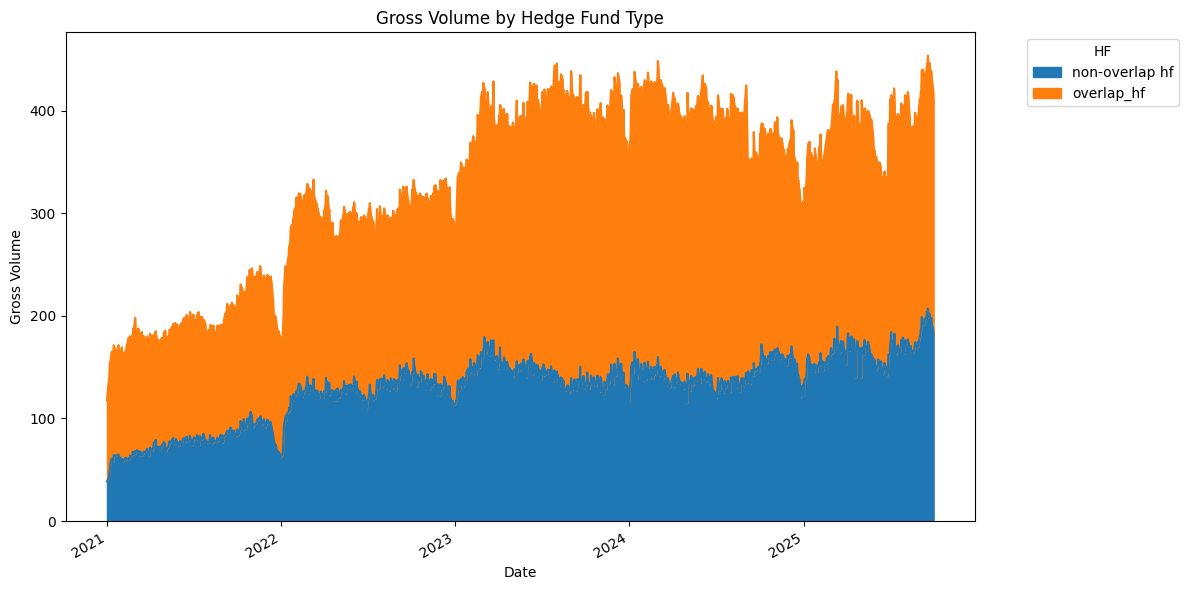

In [398]:
# Gross volume plot
pivot_gross = df.groupby(['business_date', 'hf'])['gross_volume'].sum().unstack(fill_value=0)

pivot_gross.plot.area(stacked=True, figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Gross Volume')
plt.title('Gross Volume by Hedge Fund Type')
plt.legend(title='HF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

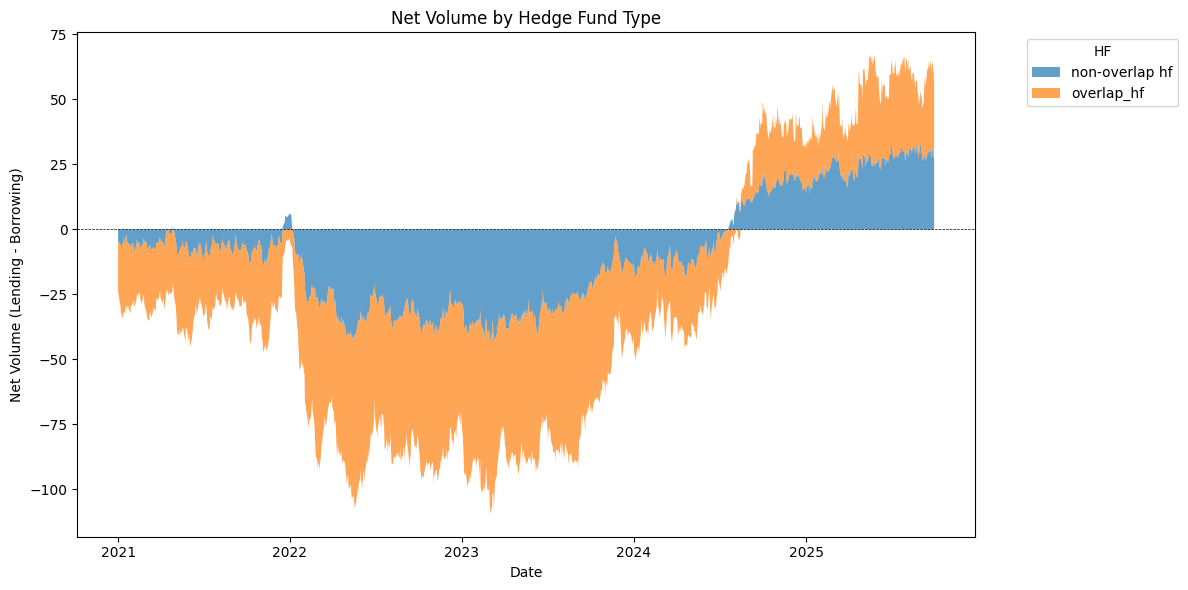

In [399]:
pivot_net = df.groupby(['business_date', 'hf'])['net_volume'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'overlap_hf': 'C1', 'non-overlap hf': 'C0'}  # adjust to your column names
col_list = pivot_net.columns.tolist()
color_list = [colors[col] for col in col_list]

# Stack positive values (net lending)
pivot_pos = pivot_net.clip(lower=0)
ax.stackplot(pivot_pos.index, *[pivot_pos[col] for col in col_list], colors=color_list, labels=col_list, alpha=0.7)

# Stack negative values (net borrowing)
pivot_neg = pivot_net.clip(upper=0)
ax.stackplot(pivot_neg.index, *[pivot_neg[col] for col in col_list], colors=color_list, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net Volume (Lending - Borrowing)')
ax.set_title('Net Volume by Hedge Fund Type')
ax.legend(title='HF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [400]:
df.groupby(['entity_id', 'hf'])['gross_volume'].sum().reset_index().nlargest(10, 'gross_volume')

,entity_id,hf,gross_volume
178,FJV0KIIMRXLMWV5QT846,overlap_hf,59639.180336
191,O1XNTICYRCAHEAMEQI31,overlap_hf,47619.467851
192,P5XEQYFJP74DYQX88M80,overlap_hf,25661.866957
25,2CNR4I7RPCUNYMQ52H12,non-overlap hf,25614.799777
64,5493008P9DJX0WNGA303,overlap_hf,23700.409735
74,549300CSOBZVGIW07Z43,overlap_hf,18548.156895
70,549300APE0JGFJ9JMB36,non-overlap hf,16230.460823
117,549300RXYC2IDG39CW23,overlap_hf,14465.419637
93,549300HY72WJJ6KYOB71,non-overlap hf,13992.498757
179,FUKBWKZPQPD7DNK1WY51,non-overlap hf,13521.499312


## USD

In [401]:
# Data prep
query = f"""

SELECT business_date, borrower_id as entity_id,
CASE WHEN borrower_id IN {final_hf} THEN 'overlap_hf' ELSE 'non-overlap hf' END AS hf, 
SUM(nominal_value) as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND ((borrower_country_residence = 'KY' AND s_borrower.sector = 'IF') OR borrower_id IN {final_hf})
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY business_date, entity_id, hf
ORDER BY business_date, entity_id, hf

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_34340\3378577171.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [402]:
# Data prep
query = f"""

SELECT business_date, lender_id as entity_id,
CASE WHEN lender_id IN {final_hf} THEN 'overlap_hf' ELSE 'non-overlap hf' END AS hf, 
SUM(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND ((lender_country_residence = 'KY' AND s_lender.sector = 'IF') OR lender_id IN {final_hf})
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY business_date, entity_id, hf
ORDER BY business_date, entity_id, hf

"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_34340\3401136298.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [403]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'hf'], how = 'outer')

In [404]:
len(df)

114556

In [405]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [406]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [407]:
df['net_volume'] = ( df['borrowing_volume'] - df['lending_volume'])/1e9

In [408]:
df['gross_volume'] = (df['borrowing_volume'] + df['lending_volume'])/1e9

In [409]:
df.head()

,business_date,entity_id,hf,borrowing_volume,lending_volume,net_volume,gross_volume
0,2021-01-04,0QPLVC7REZNB7RWGY574,non-overlap hf,3.000000e+08,8.200003e+07,0.218000,0.382000
1,2021-01-04,0XXENSNEYD5BSB49GB59,non-overlap hf,2.903190e+08,0.000000e+00,0.290319,0.290319
2,2021-01-04,17MLVAZ72NADQE8UDF88,non-overlap hf,5.344886e+08,2.051748e+08,0.329314,0.739663
3,2021-01-04,254900D33TBU3WASUT96,overlap_hf,1.047500e+08,0.000000e+00,0.104750,0.104750
4,2021-01-04,29C7VLB4JHJG5S6I8Q07,non-overlap hf,1.128134e+09,0.000000e+00,1.128134,1.128134


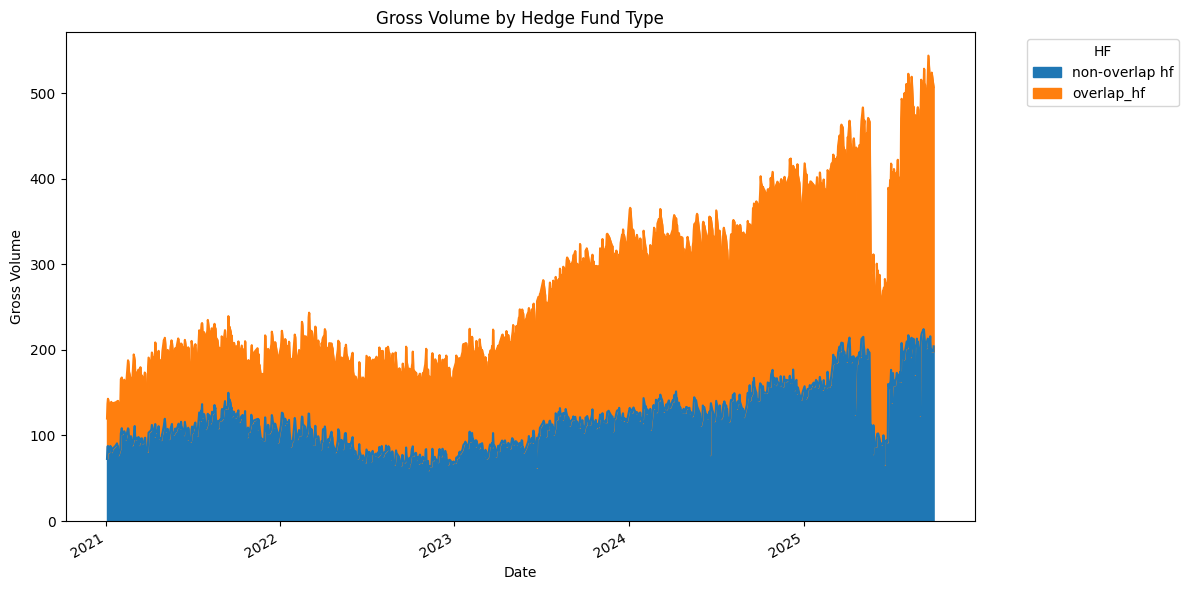

In [410]:
# Gross volume plot
pivot_gross = df.groupby(['business_date', 'hf'])['gross_volume'].sum().unstack(fill_value=0)

pivot_gross.plot.area(stacked=True, figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Gross Volume')
plt.title('Gross Volume by Hedge Fund Type')
plt.legend(title='HF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

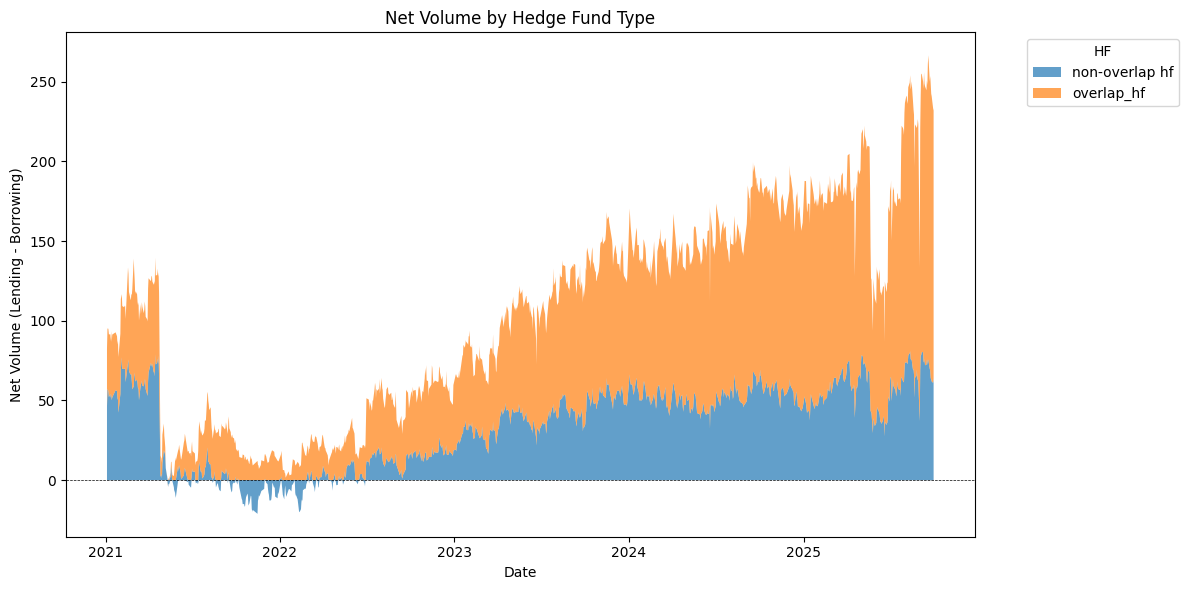

In [411]:
pivot_net = df.groupby(['business_date', 'hf'])['net_volume'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'overlap_hf': 'C1', 'non-overlap hf': 'C0'}  # adjust to your column names
col_list = pivot_net.columns.tolist()
color_list = [colors[col] for col in col_list]

# Stack positive values (net lending)
pivot_pos = pivot_net.clip(lower=0)
ax.stackplot(pivot_pos.index, *[pivot_pos[col] for col in col_list], colors=color_list, labels=col_list, alpha=0.7)

# Stack negative values (net borrowing)
pivot_neg = pivot_net.clip(upper=0)
ax.stackplot(pivot_neg.index, *[pivot_neg[col] for col in col_list], colors=color_list, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net Volume (Lending - Borrowing)')
ax.set_title('Net Volume by Hedge Fund Type')
ax.legend(title='HF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [412]:
df.groupby(['entity_id', 'hf'])['gross_volume'].sum().reset_index().nlargest(10, 'gross_volume')

,entity_id,hf,gross_volume
218,O1XNTICYRCAHEAMEQI31,overlap_hf,30482.985456
219,P5XEQYFJP74DYQX88M80,overlap_hf,26323.931519
201,FJV0KIIMRXLMWV5QT846,overlap_hf,24760.644267
125,549300KM4DRKLEPZUO76,non-overlap hf,19315.013474
150,549300RXYC2IDG39CW23,overlap_hf,18011.377309
202,FUKBWKZPQPD7DNK1WY51,non-overlap hf,12484.898858
73,5493008P9DJX0WNGA303,overlap_hf,11291.339194
197,DBMPQSXT0LEURZ0IGP72,non-overlap hf,10466.333794
27,2CNR4I7RPCUNYMQ52H12,non-overlap hf,8705.582230
86,549300CSOBZVGIW07Z43,overlap_hf,8056.147400


## Are the remaining funds not present at all in EMIR?
- no

In [413]:
# Data prep
query = f"""

SELECT DISTINCT reference_period
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated 
WHERE reference_period >= '2025-01-01'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR", "USD")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND other_cpty_id IN ('549300KM4DRKLEPZUO76', 'FUKBWKZPQPD7DNK1WY51', 'DBMPQSXT0LEURZ0IGP72', '2CNR4I7RPCUNYMQ52H12', '549300APE0JGFJ9JMB36', '549300HY72WJJ6KYOB71')

"""

df_check = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_34340\689112701.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql_query(query, cnxn)


In [414]:
df_check

,reference_period
